[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Forecasting_Electricity_Demand_RNN_pt2.ipynb)

# Forecasting Electricity Demand, Part 2: 2020, the Year the Data Changed
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

The capstone trained on 2017-2018 and tested on 2019. **2020 exists in the file and the model has never seen it** - and in March 2020 the world changed. This notebook downloads the saved day-ahead model (and the one-hour model from the explainability notebook), rebuilds the scaler exactly as before, and asks:

1. How does a model trained on normal years do on a **year that isn't** - month by month?
2. What does the **autoregressive roll-forward** look like on unseen data, next to the multi-output forecast?
3. Which features does the day-ahead model actually use?

No training. Two downloads, one scaler, a lot of honest plots.

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 17-pt2 — Demand Pt 2b: reload, forecast 2020, and watch the distribution shift
- Two artifacts: the day-ahead Dense(24) model from the capstone, and the one-hour model from the explainability notebook. Rebuild the SAME scaler from 2017-18 - the scaler is part of the model, say it again.
- Prove the reload: 2019 day-ahead MAE ~167 MW, same as the capstone. Then 2020, a year it never saw.
- MAE by month, 2019 vs 2020, against seasonal naive: Jan-Mar 2020 is as good as 2019, then April-May 2020 gets WORSE where 2019 got better (126->153, 129->170) - the lockdown; demand fell, the weather said it shouldn't have. August 2020 is the worst month (288 vs 214) - a hot summer with everyone at home. Year MAE 167 -> 181. That's distribution shift, on screen, from a model you trained.
- Roll the one-hour model forward 24 steps on 2020 (weather frozen = honest): 36 / 195 / 296 / 448 MW at h=1/6/12/24 vs the day-ahead model's 83 / 159 / 194 / 215 and naive ~240. Same compounding you saw on 2019; multi-output wins from hour 6. Two years, same lesson - that's the point of testing on unseen data.
- Permutation on the day-ahead model: demand's own past still dominates; the clock second; weather third. Close: would you retrain on 2020? (Trick question - which weeks?)
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from urllib.request import urlretrieve
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix, f1_score
from keras.models import load_model
import keras
keras.utils.set_random_seed(5509)
from sklearn.preprocessing import MinMaxScaler

## Rebuild the capstone's prep, then carve out 2020

In [2]:
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"]).sort_values("Datetime").set_index("Datetime").ffill()

def add_clock(d):
    d = d.copy()
    d["hour_sin"] = np.sin(2*np.pi*d.index.hour/24);      d["hour_cos"] = np.cos(2*np.pi*d.index.hour/24)
    d["dow_sin"]  = np.sin(2*np.pi*d.index.dayofweek/7);  d["dow_cos"]  = np.cos(2*np.pi*d.index.dayofweek/7)
    return d

feats = ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]   # Demand LAST
all_ = add_clock(df)[feats]
train, test19, test20 = all_.loc["2017":"2018"], all_.loc["2019"], all_.loc["2020"]
sc   = MinMaxScaler().fit(train)               # the capstone's scaler: fit on 2017-18 ONLY - it is part of the model
sc_y = MinMaxScaler().fit(train[["Demand"]])
s19, s20 = sc.transform(test19), sc.transform(test20)

def split_multistep(seqs, n_in, n_out):
    X, y = [], []
    for i in range(len(seqs) - n_in - n_out + 1):
        X.append(seqs[i:i+n_in, :]); y.append(seqs[i+n_in:i+n_in+n_out, -1])
    return np.array(X), np.array(y)

n_in, n_out = 24*7, 24
X19, y19 = split_multistep(s19, n_in, n_out)
X20, y20 = split_multistep(s20, n_in, n_out)
to_mw = lambda a: sc_y.inverse_transform(a.reshape(-1, 1)).reshape(a.shape)
print("2019 windows:", X19.shape, "| 2020 windows (never seen):", X20.shape)

2019 windows: (8569, 168, 8) | 2020 windows (never seen): (8593, 168, 8)


## Download the two saved models and prove the reload

In [3]:
urlretrieve("https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/models/Forecasting_Electricity_Demand_RNN_dayahead.keras", "dayahead.keras")
urlretrieve("https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/models/Explaining_an_LSTM.keras", "onehour.keras")
dayahead, onehour = load_model("dayahead.keras"), load_model("onehour.keras")
print("day-ahead model input:", dayahead.input_shape, "-> outputs:", dayahead.output_shape)
print("one-hour  model input:", onehour.input_shape,  "-> outputs:", onehour.output_shape)

p19 = to_mw(dayahead.predict(X19, verbose=0)); t19 = to_mw(y19)
print(f"2019 day-ahead MAE (averaged over 24 horizons): {np.abs(p19 - t19).mean():.1f} MW   (the capstone reported ~167)")

day-ahead model input: (None, 168, 8) -> outputs: (None, 24)
one-hour  model input: (None, 24, 8) -> outputs: (None, 1)


2019 day-ahead MAE (averaged over 24 horizons): 167.3 MW   (the capstone reported ~167)


## 1. The unseen year, month by month

Same model, same scaler, a year it never saw. Score the day-ahead forecast by month for 2019 and 2020, with the seasonal-naive baseline for each.

2020 day-ahead MAE: 181.0 MW   (2019: 167.3)


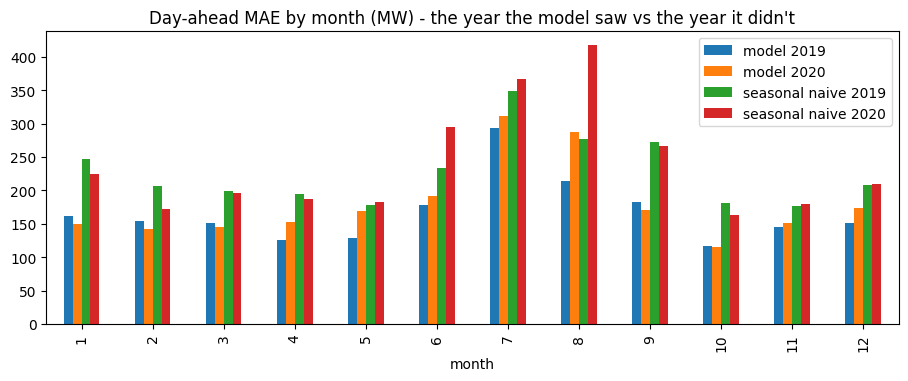

,model 2019,model 2020,seasonal naive 2019,seasonal naive 2020
Datetime,,,,
1,162.0,150.0,247.0,225.0
2,154.0,142.0,207.0,172.0
3,152.0,146.0,199.0,197.0
4,126.0,153.0,194.0,187.0
5,129.0,170.0,177.0,183.0
6,179.0,191.0,233.0,295.0
7,294.0,311.0,349.0,367.0
8,214.0,288.0,277.0,417.0
9,182.0,170.0,272.0,267.0


In [4]:
p20 = to_mw(dayahead.predict(X20, verbose=0)); t20 = to_mw(y20)
print(f"2020 day-ahead MAE: {np.abs(p20 - t20).mean():.1f} MW   (2019: {np.abs(p19 - t19).mean():.1f})")

def by_month(pred, truth, idx):
    err = pd.Series(np.abs(pred - truth).mean(axis=1), index=idx[n_in:n_in+len(pred)])   # error of the forecast issued at each origin
    return err.groupby(err.index.month).mean()
def naive_by_month(d):
    y = d["Demand"]; e = (y - y.shift(24)).abs()
    return e.groupby(e.index.month).mean()

m = pd.DataFrame({"model 2019": by_month(p19, t19, test19.index), "model 2020": by_month(p20, t20, test20.index),
                  "seasonal naive 2019": naive_by_month(test19), "seasonal naive 2020": naive_by_month(test20)})
m.plot(kind="bar", figsize=(11, 3.8), title="Day-ahead MAE by month (MW) - the year the model saw vs the year it didn't"); plt.xlabel("month"); plt.show()
m.round(0)

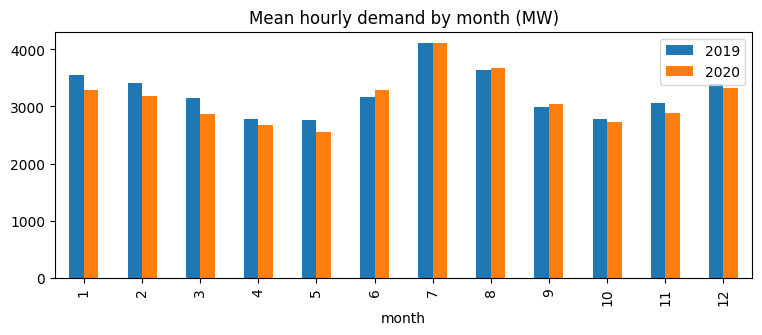

In [5]:
# what happened: demand by month, 2019 vs 2020
pd.DataFrame({"2019": test19["Demand"].groupby(test19.index.month).mean(), "2020": test20["Demand"].groupby(test20.index.month).mean()}).plot(
    kind="bar", figsize=(9, 3.2), title="Mean hourly demand by month (MW)"); plt.xlabel("month"); plt.show()

## 2. Autoregressive roll-forward on the unseen year

The one-hour model, rolled 24 steps with the **weather frozen** at the last observed hour (no forecast - the honest version) and demand replaced by its own predictions. Next to it, the multi-output model's day-ahead forecast on the same 2020 origins.

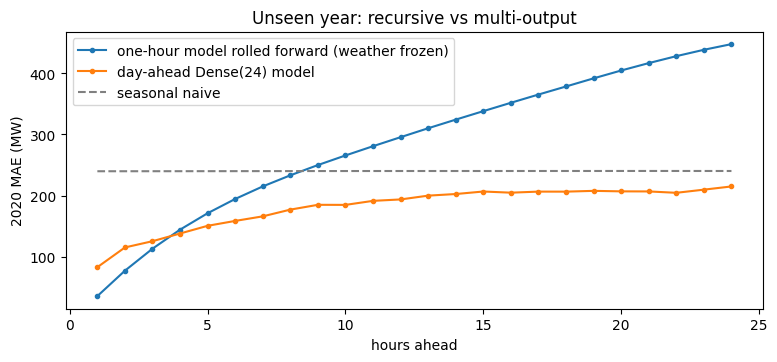

,recursive,multi-output,seasonal naive
h=1,35.5,82.8,239.8
h=6,194.5,158.5,240.0
h=12,295.6,193.7,240.2
h=24,447.8,214.9,240.2


In [6]:
weather_cols = [feats.index(c) for c in ["BDL_tmpf", "BDL_dwpf", "BDL_relh"]]
n_steps = onehour.input_shape[1]                                          # 24

def recursive(model, seqs, n_steps, n_out):
    n_orig = len(seqs) - n_steps - n_out + 1
    window = np.stack([seqs[i:i+n_steps] for i in range(n_orig)]); preds = np.zeros((n_orig, n_out))
    for h in range(n_out):
        p = model.predict(window, verbose=0).ravel(); preds[:, h] = p
        future = np.stack([seqs[i+n_steps+h] for i in range(n_orig)]).copy()   # real row: we take only the CLOCK from it
        future[:, weather_cols] = window[:, -1, weather_cols]                  # weather frozen
        future[:, -1] = p                                                      # demand = our own prediction
        window = np.concatenate([window[:, 1:, :], future[:, None, :]], axis=1)
    return preds

rec20 = to_mw(recursive(onehour, s20, n_steps, n_out))
truth_rec = to_mw(np.stack([s20[i+n_steps:i+n_steps+n_out, -1] for i in range(rec20.shape[0])]))
mae_rec = np.abs(rec20 - truth_rec).mean(axis=0)
mae_mimo = np.abs(p20 - t20).mean(axis=0)
dem = test20["Demand"].values
naive = np.array([np.abs(dem[n_in+h:n_in+h+len(p20)] - dem[n_in+h-24:n_in+h-24+len(p20)]).mean() for h in range(n_out)])

plt.figure(figsize=(9, 3.6)); hrs = np.arange(1, n_out+1)
plt.plot(hrs, mae_rec, marker=".", label="one-hour model rolled forward (weather frozen)")
plt.plot(hrs, mae_mimo, marker=".", label="day-ahead Dense(24) model")
plt.plot(hrs, naive, "--", color="gray", label="seasonal naive")
plt.xlabel("hours ahead"); plt.ylabel("2020 MAE (MW)"); plt.title("Unseen year: recursive vs multi-output"); plt.legend(); plt.show()
pd.DataFrame({"recursive": mae_rec, "multi-output": mae_mimo, "seasonal naive": naive}, index=[f"h={h}" for h in hrs]).round(1).iloc[[0, 5, 11, 23]]

## 3. Permutation importance of the day-ahead model (on 2020)

Shuffle one feature across the 168-hour windows and re-score the whole 24-hour forecast.

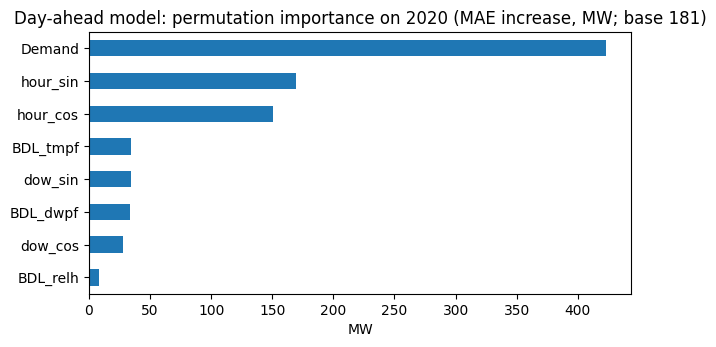

In [7]:
rng = np.random.default_rng(5509)
base = np.abs(p20 - t20).mean(); imp = {}
for j, f in enumerate(feats):
    Xp = X20.copy(); Xp[:, :, j] = Xp[rng.permutation(len(Xp)), :, j]
    imp[f] = np.abs(to_mw(dayahead.predict(Xp, verbose=0)) - t20).mean() - base
pd.Series(imp).sort_values().plot(kind="barh", figsize=(7, 3.4), title=f"Day-ahead model: permutation importance on 2020 (MAE increase, MW; base {base:.0f})"); plt.xlabel("MW"); plt.show()

## What you just saw

- **A saved model plus its scaler** reproduces the capstone exactly, on a different day, in a different notebook. Ship the scaler with the model.
- **Distribution shift is visible, not theoretical.** The day-ahead error jumps in spring 2020 because demand fell while the weather and the clock said it shouldn't - the model had no way to know about a lockdown.
- **The autoregressive lesson survives on unseen data.** Recursive is best for the first hours and loses to the day-ahead model (and eventually to seasonal naive) as its own errors pile up - same shape as 2019.
- The day-ahead model runs on **demand's own history**, then the clock, then the weather - the same story the explainability notebook told about the one-hour model.

## On your own
- Retrain the capstone on **2017-2020** and re-score 2021. Does including the strange year help or hurt? Which weeks would you drop?
- Roll the one-hour model forward with *yesterday's* weather instead of frozen weather. Closer to the perfect-foresight curve, or not?
- Score the peak-hour classifier idea on 2020: does the top-10% threshold from 2017-18 still make sense when demand fell?